# 225 — Where the shared k-mers land inside an MHC molecule, across nine species

**Question:** notebooks 211 and 212 asked, on the human–mouse run, where kmerseek's matched
regions fall *within* a class I or class II molecule — the peptide-binding platform, or the
immunoglobulin scaffold underneath it. This notebook asks the same three questions of the
midi run, which has nine target species instead of one and the full alphabet × k sweep.

There is a specific reason to redo it now. Notebook
[223](./223_mhc_platform_vs_ig_domain.ipynb) showed that the run's headline metric —
domain recall at IoU ≥ 0.5 — is a **boundary** metric: it is bounded by the domain's length
fraction and rescued only by single-domain targets, so it can score a domain as missed while
every call lands squarely on it. The measurement in this notebook does not use a threshold at
all. It counts, residue by residue, how much matched k-mer sequence falls inside each domain
and divides by that domain's length. Nothing here can be an artifact of where a cut-off sits.

Three panels, following 211 §1, 212 §2 and 212 §4 in turn.

matched region windows : 31_233_188
curated MHC genes      : 22
alphabets              : 9  (7 HP, 2 coarse)
scored domain intervals: 43 (21 platform, 22 Ig)
shape: (11, 3)
┌───────────────────┬──────────────────────────┬─────┐
│ mhc_class         ┆ role                     ┆ len │
│ ---               ┆ ---                      ┆ --- │
│ str               ┆ str                      ┆ u32 │
╞═══════════════════╪══════════════════════════╪═════╡
│ I classical       ┆ Ig C1-set                ┆ 3   │
│ I classical       ┆ peptide-binding platform ┆ 3   │
│ I non-classical   ┆ Ig C1-set                ┆ 3   │
│ I non-classical   ┆ peptide-binding platform ┆ 3   │
│ I related (MIC)   ┆ Ig C1-set                ┆ 2   │
│ …                 ┆ …                        ┆ …   │
│ II alpha          ┆ Ig C1-set                ┆ 6   │
│ II alpha          ┆ peptide-binding platform ┆ 6   │
│ II beta           ┆ Ig C1-set                ┆ 7   │
│ II beta           ┆ peptide-binding platform ┆ 7   │
│ 

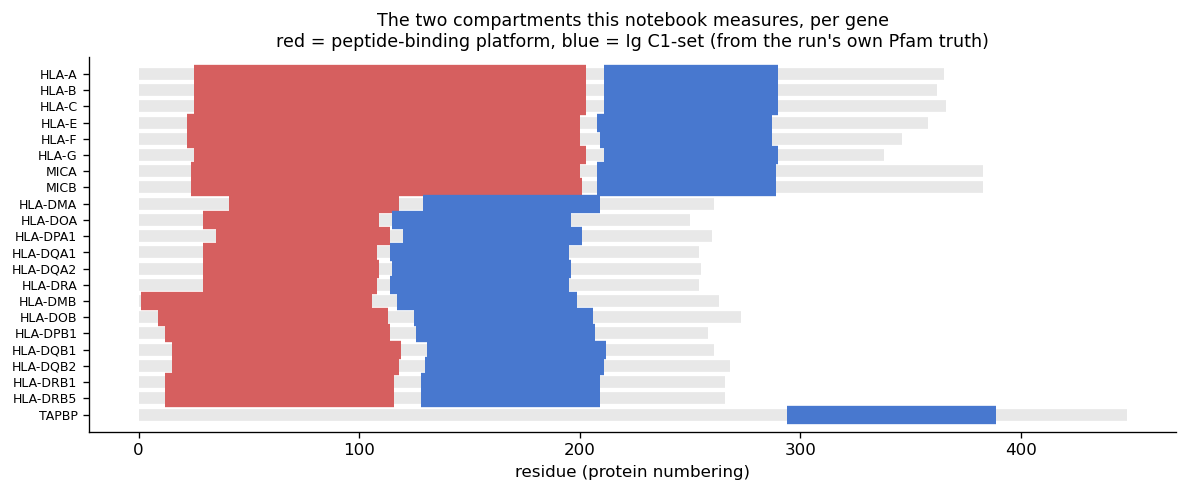

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import mhc_region_utils as mu
import ortholog_analysis_utils as ou

FIG_DIR = Path("../figures")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

# Matched regions for the 24 curated MHC genes across the full k sweep of nine alphabets,
# both query- and target-side. Rows are individual matched k-mer windows: region_end minus
# region_start is k, and region_end tops out at exactly the protein length, so coordinates
# are 0-based half-open. Residues in 1-based protein numbering are region_start+1 .. region_end.
SWEEP = mu.EXTRACT_DIR / "mhc_region_ksize_sweep.parquet"

gene_map = mu.load_chr6_gene_map()
core = gene_map.filter(pl.col("mhc_class").is_not_null())
truth = mu.load_human_truth()

# Per-gene domain boundaries come from the run's own Pfam truth rather than from HLA-A
# constants. 212 used ou.ARD_I / ou.IG_I, which are HLA-A's boundaries applied to every gene;
# using each gene's real interval is exact, covers class II (whose architecture differs), and
# keeps this notebook on the same intervals 223 scored.
ARCH = (truth.rename({"accession": "query_acc"})
             .join(core.select(query_acc="accession", hgnc_symbol="hgnc_symbol",
                               mhc_class="mhc_class"), on="query_acc", how="inner")
             .with_columns(role=mu.domain_role(pl.col("pfam_id")))
             .filter(pl.col("role").is_in(["peptide-binding platform", "Ig C1-set"]))
             .select("query_acc", "hgnc_symbol", "mhc_class", "pfam_id", "role",
                     "domain_start", "domain_end", "protein_length"))

ALPHABETS = (pl.scan_parquet(SWEEP).select("alphabet").unique().collect()["alphabet"]
             .sort().to_list())
HP = [a for a in ALPHABETS if a.startswith("hp_")]
COARSE = [a for a in ALPHABETS if not a.startswith("hp_")]
ALPHA_COLOR = {}
for i, a in enumerate(HP):
    ALPHA_COLOR[a] = plt.get_cmap("Reds")(0.45 + 0.08 * i)
for i, a in enumerate(COARSE):
    ALPHA_COLOR[a] = plt.get_cmap("Blues")(0.45 + 0.18 * i)

n_rows = pl.scan_parquet(SWEEP).select(pl.len()).collect().item()
print(f"matched region windows : {n_rows:_}")
print(f"curated MHC genes      : {ARCH['query_acc'].n_unique()}")
print(f"alphabets              : {len(ALPHABETS)}  ({len(HP)} HP, {len(COARSE)} coarse)")
print(f"scored domain intervals: {ARCH.height} "
      f"({ARCH.filter(pl.col('role') == 'peptide-binding platform').height} platform, "
      f"{ARCH.filter(pl.col('role') == 'Ig C1-set').height} Ig)")
arch_tbl = ARCH.group_by("mhc_class", "role").len().sort("mhc_class", "role")
print(arch_tbl)

fig, ax = plt.subplots(figsize=(10, 4.2))
genes = ARCH.select("hgnc_symbol", "mhc_class").unique().sort("mhc_class", "hgnc_symbol")
glist = genes["hgnc_symbol"].to_list()
for i, g in enumerate(glist):
    rows_g = ARCH.filter(pl.col("hgnc_symbol") == g)
    L = rows_g["protein_length"][0]
    ax.plot([0, L], [i, i], color="#e8e8e8", lw=7, solid_capstyle="butt", zorder=1)
    for d in rows_g.iter_rows(named=True):
        ax.plot([d["domain_start"], d["domain_end"]], [i, i],
                color=mu.DOMAIN_ROLE_COLORS[d["role"]], lw=11, solid_capstyle="butt", zorder=2)
ax.set_yticks(range(len(glist)))
ax.set_yticklabels(glist, fontsize=7.5)
ax.invert_yaxis()
ax.set_xlabel("residue (protein numbering)")
ax.set_title("The two compartments this notebook measures, per gene\n"
             "red = peptide-binding platform, blue = Ig C1-set (from the run's own Pfam truth)",
             fontsize=10.5)
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "225_scored_compartments.png", dpi=200)

## 1. Recovery against k, one line per alphabet (after 211 §1)

211 plotted ROC-AUC against k with a panel per MHC class and a row per label policy. The midi
run has no ortholog labels — it scores domain calls — so the y axis here is the fraction of
that class's domain instances recovered, and the rows are target species rather than label
policies. That is the axis 211 could not have: it only had mouse.

Both scoring rules are shown, because 223 established they disagree. **Covered** means a call
overlapped at least half the domain; **delimited** additionally requires IoU ≥ 0.5. The gap
between the two lines is the boundary artifact, drawn per alphabet and per k.

Best arm per group and species, by fraction covered:
shape: (6, 7)
┌────────────────────────┬───────────┬────────────────────┬───────┬─────────┬───────────┬────────┐
│ group                  ┆ species   ┆ alphabet           ┆ ksize ┆ covered ┆ delimited ┆ n_true │
│ ---                    ┆ ---       ┆ ---                ┆ ---   ┆ ---     ┆ ---       ┆ ---    │
│ str                    ┆ str       ┆ str                ┆ i64   ┆ f64     ┆ f64       ┆ i64    │
╞════════════════════════╪═══════════╪════════════════════╪═══════╪═════════╪═══════════╪════════╡
│ class I platform + Ig  ┆ chicken   ┆ hp_kyte_doolittle2 ┆ 19    ┆ 0.0     ┆ 0.0       ┆ 16     │
│ class I platform + Ig  ┆ mouse     ┆ dayhoff6           ┆ 8     ┆ 0.312   ┆ 0.188     ┆ 16     │
│ class I platform + Ig  ┆ zebrafish ┆ dayhoff6           ┆ 8     ┆ 0.0     ┆ 0.0       ┆ 16     │
│ class II platform + Ig ┆ chicken   ┆ hp_thomas_dill2    ┆ 19    ┆ 0.038   ┆ 0.038     ┆ 26     │
│ class II platform + Ig ┆ mouse     ┆ hp_

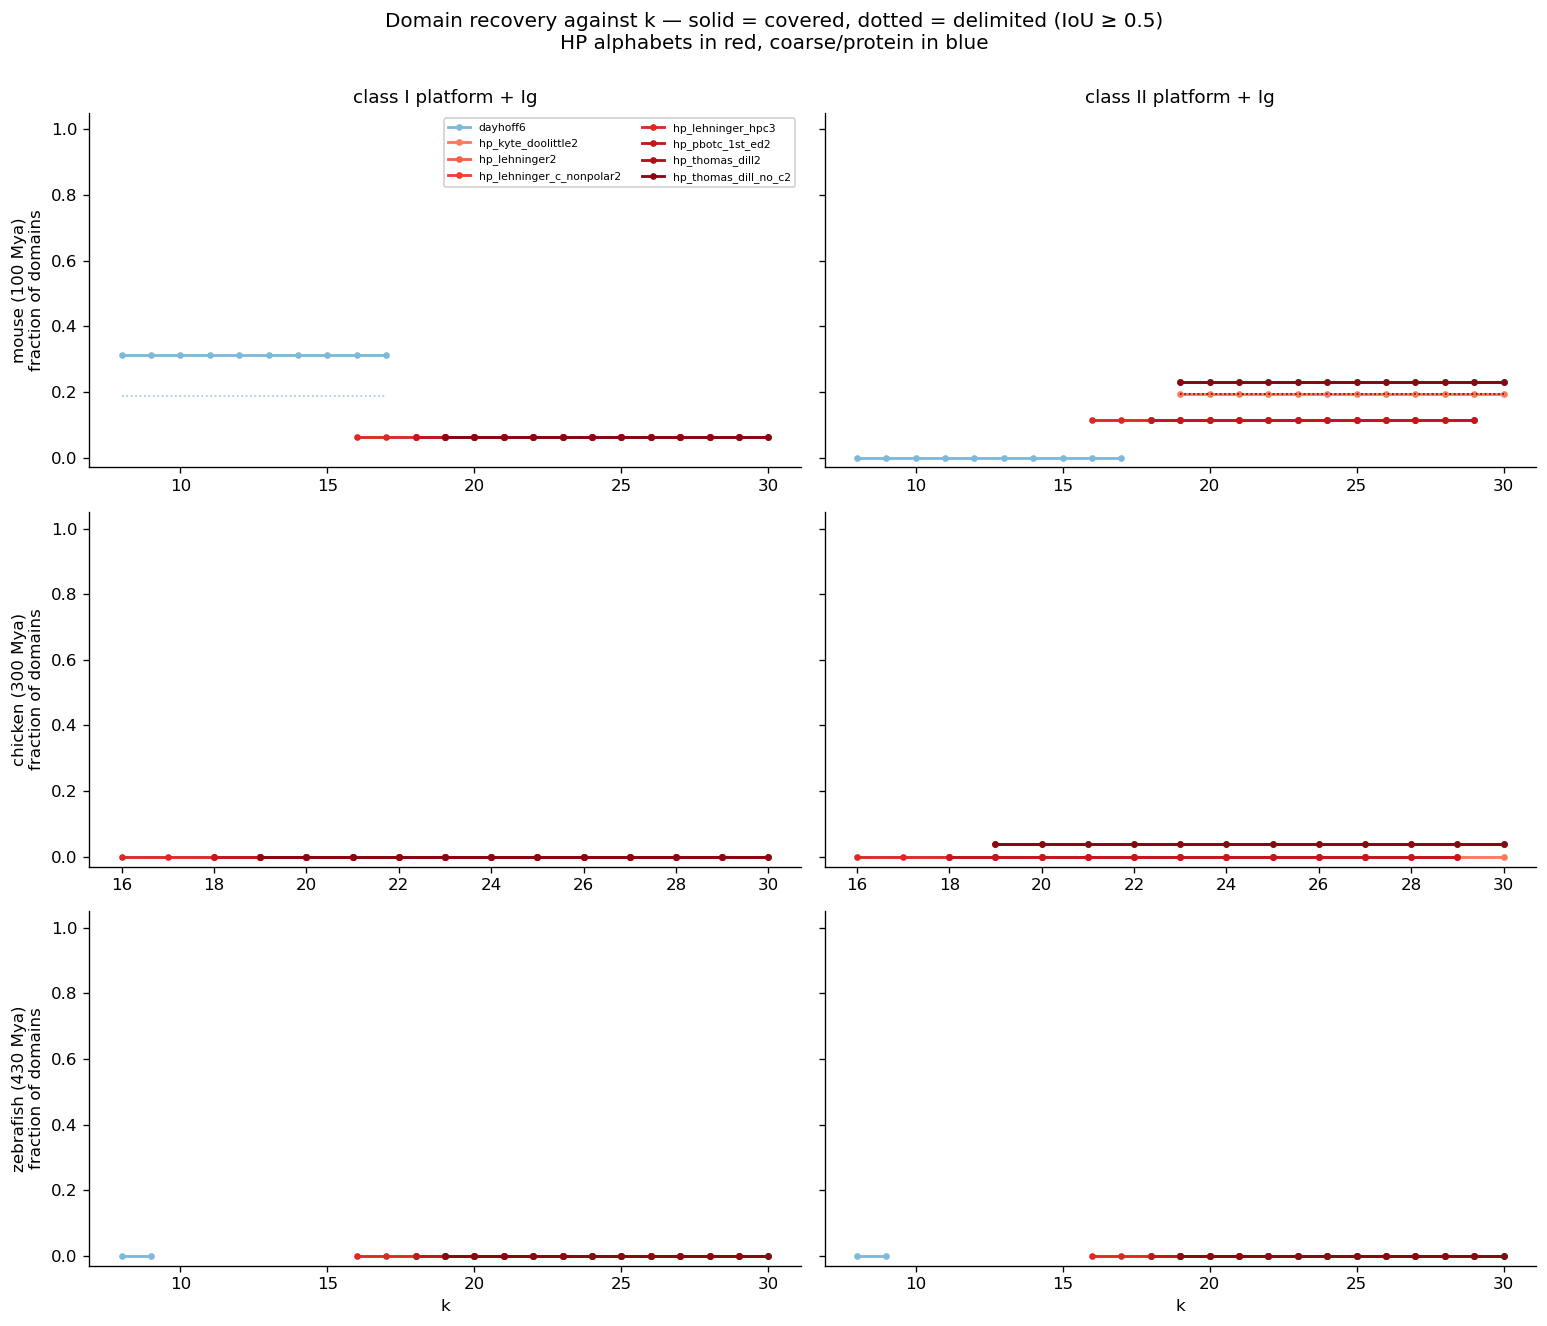

In [2]:
dl = (mu.load_domain_level()
        .filter(pl.col("tool") == "kmerseek")
        .with_columns(alphabet=pl.col("variant").str.replace(r"_k\d+_lc(True|False)$", ""),
                      ksize=pl.col("variant").str.extract(r"_k(\d+)_lc", 1).cast(pl.Int64),
                      lc=pl.col("variant").str.ends_with("lcTrue"))
        .filter(pl.col("lc") & pl.col("alphabet").is_in(ALPHABETS)))

GROUPS = {"class I platform + Ig": pl.col("mhc_class").str.starts_with("I "),
          "class II platform + Ig": pl.col("mhc_class").str.starts_with("II")}
SPP = ["mouse", "chicken", "zebrafish"]

rows = []
for gname, gexpr in GROUPS.items():
    tgt = ARCH.filter(gexpr).select("query_acc", "pfam_id")
    n_true = tgt.height
    for sp in SPP:
        got = dl.filter(pl.col("species") == sp)
        for a in ALPHABETS:
            for k in sorted(got.filter(pl.col("alphabet") == a)["ksize"].unique().to_list()):
                arm = got.filter((pl.col("alphabet") == a) & (pl.col("ksize") == k))
                j = tgt.join(arm.select("query_acc", "pfam_id", "found", "best_cover"),
                             on=["query_acc", "pfam_id"], how="left")
                rows.append({
                    "group": gname, "species": sp, "alphabet": a, "ksize": k,
                    "n_true": n_true,
                    "delimited": j["found"].fill_null(False).sum() / n_true,
                    "covered": (j["best_cover"].fill_null(0.0) >= 0.5).sum() / n_true})
rec = pl.DataFrame(rows)
best = (rec.sort("covered", descending=True).group_by("group", "species").head(1)
           .select("group", "species", "alphabet", "ksize",
                   pl.col("covered").round(3), pl.col("delimited").round(3), "n_true"))
print("Best arm per group and species, by fraction covered:")
with pl.Config(tbl_rows=20, tbl_width_chars=170):
    print(best.sort("group", "species"))

fig, axes = plt.subplots(len(SPP), 2, figsize=(13, 11), sharey=True)
for r, sp in enumerate(SPP):
    for c, gname in enumerate(GROUPS):
        ax = axes[r, c]
        for a in ALPHABETS:
            s = rec.filter((pl.col("group") == gname) & (pl.col("species") == sp)
                           & (pl.col("alphabet") == a)).sort("ksize")
            if s.height == 0:
                continue
            ax.plot(s["ksize"], s["covered"], marker="o", ms=3, lw=1.7,
                    color=ALPHA_COLOR[a], label=a if (r == 0 and c == 0) else None)
            ax.plot(s["ksize"], s["delimited"], marker=None, lw=1.0, ls=":",
                    color=ALPHA_COLOR[a], alpha=0.8)
        ax.set_ylim(-0.03, 1.05)
        if r == 0:
            ax.set_title(gname, fontsize=11)
        if c == 0:
            ax.set_ylabel(f"{sp} ({mu.SPECIES_MYA[sp]} Mya)\nfraction of domains")
        if r == len(SPP) - 1:
            ax.set_xlabel("k")
        for s_ in ("right", "top"):
            ax.spines[s_].set_visible(False)
axes[0, 0].legend(fontsize=6.5, ncol=2, framealpha=0.9)
fig.suptitle("Domain recovery against k — solid = covered, dotted = delimited (IoU ≥ 0.5)\n"
             "HP alphabets in red, coarse/protein in blue", y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "225_recovery_vs_ksize.png", dpi=200)

## 2. The Ig scaffold carries more shared sequence per residue than the platform (after 212 §2)

The measurement 212 introduced, and the one this notebook exists for. For every matched
k-mer window, count how many of its residues fall inside the peptide-binding platform and
how many inside the Ig C1-set domain, then divide each total by that domain's length. The
result is **matched residues per domain residue** — a density, so a 179-residue platform and
an 82-residue Ig domain are directly comparable.

A ratio above 1 means the Ig scaffold carries more shared sequence per residue than the
platform. That is the expected direction: the platform is the most polymorphic coding
sequence in the human genome and the Ig fold is shared with antibodies and T-cell receptors.

**The ratio is reported per species rather than pooled, because pooling destroys it.** Across
all nine targets the median is 0.91, which looks like no asymmetry at all. Split by species it
is 1.18 in mouse and falls monotonically to 0.82 in ciona and *E. coli*. That is not a
nuisance — it is the control. Six of the nine targets contain no MHC molecule for these genes
to be orthologous to (notebook 220), so whatever matches there is not an MHC platform or an
MHC Ig domain and has no reason to show the asymmetry. The asymmetry appears exactly where
the orthologs are.

No threshold anywhere in this calculation.

Ig / platform density ratio by target species (the asymmetry tracks where orthologs are):
shape: (9, 5)
┌─────────────┬────────┬──────────┬──────┬──────┐
│ species     ┆ median ┆ frac_gt1 ┆ n    ┆ mya  │
│ ---         ┆ ---    ┆ ---      ┆ ---  ┆ ---  │
│ str         ┆ f64    ┆ f64      ┆ u32  ┆ i64  │
╞═════════════╪════════╪══════════╪══════╪══════╡
│ mouse       ┆ 1.185  ┆ 0.634    ┆ 2079 ┆ 100  │
│ chicken     ┆ 0.888  ┆ 0.399    ┆ 1883 ┆ 300  │
│ zebrafish   ┆ 0.857  ┆ 0.368    ┆ 1855 ┆ 430  │
│ ciona       ┆ 0.823  ┆ 0.329    ┆ 1756 ┆ 550  │
│ fly         ┆ 0.946  ┆ 0.444    ┆ 1819 ┆ 600  │
│ worm        ┆ 0.863  ┆ 0.361    ┆ 1816 ┆ 650  │
│ yeast       ┆ 0.926  ┆ 0.431    ┆ 1594 ┆ 900  │
│ arabidopsis ┆ 0.906  ┆ 0.418    ┆ 1840 ┆ 1500 │
│ ecoli       ┆ 0.833  ┆ 0.38     ┆ 1427 ┆ 2000 │
└─────────────┴────────┴──────────┴──────┴──────┘

mouse only, by MHC class:
shape: (5, 6)
┌─────────────────┬────────┬───────┬───────┬─────┬───────────────────┐
│ mhc_class       ┆ median ┆ q1   

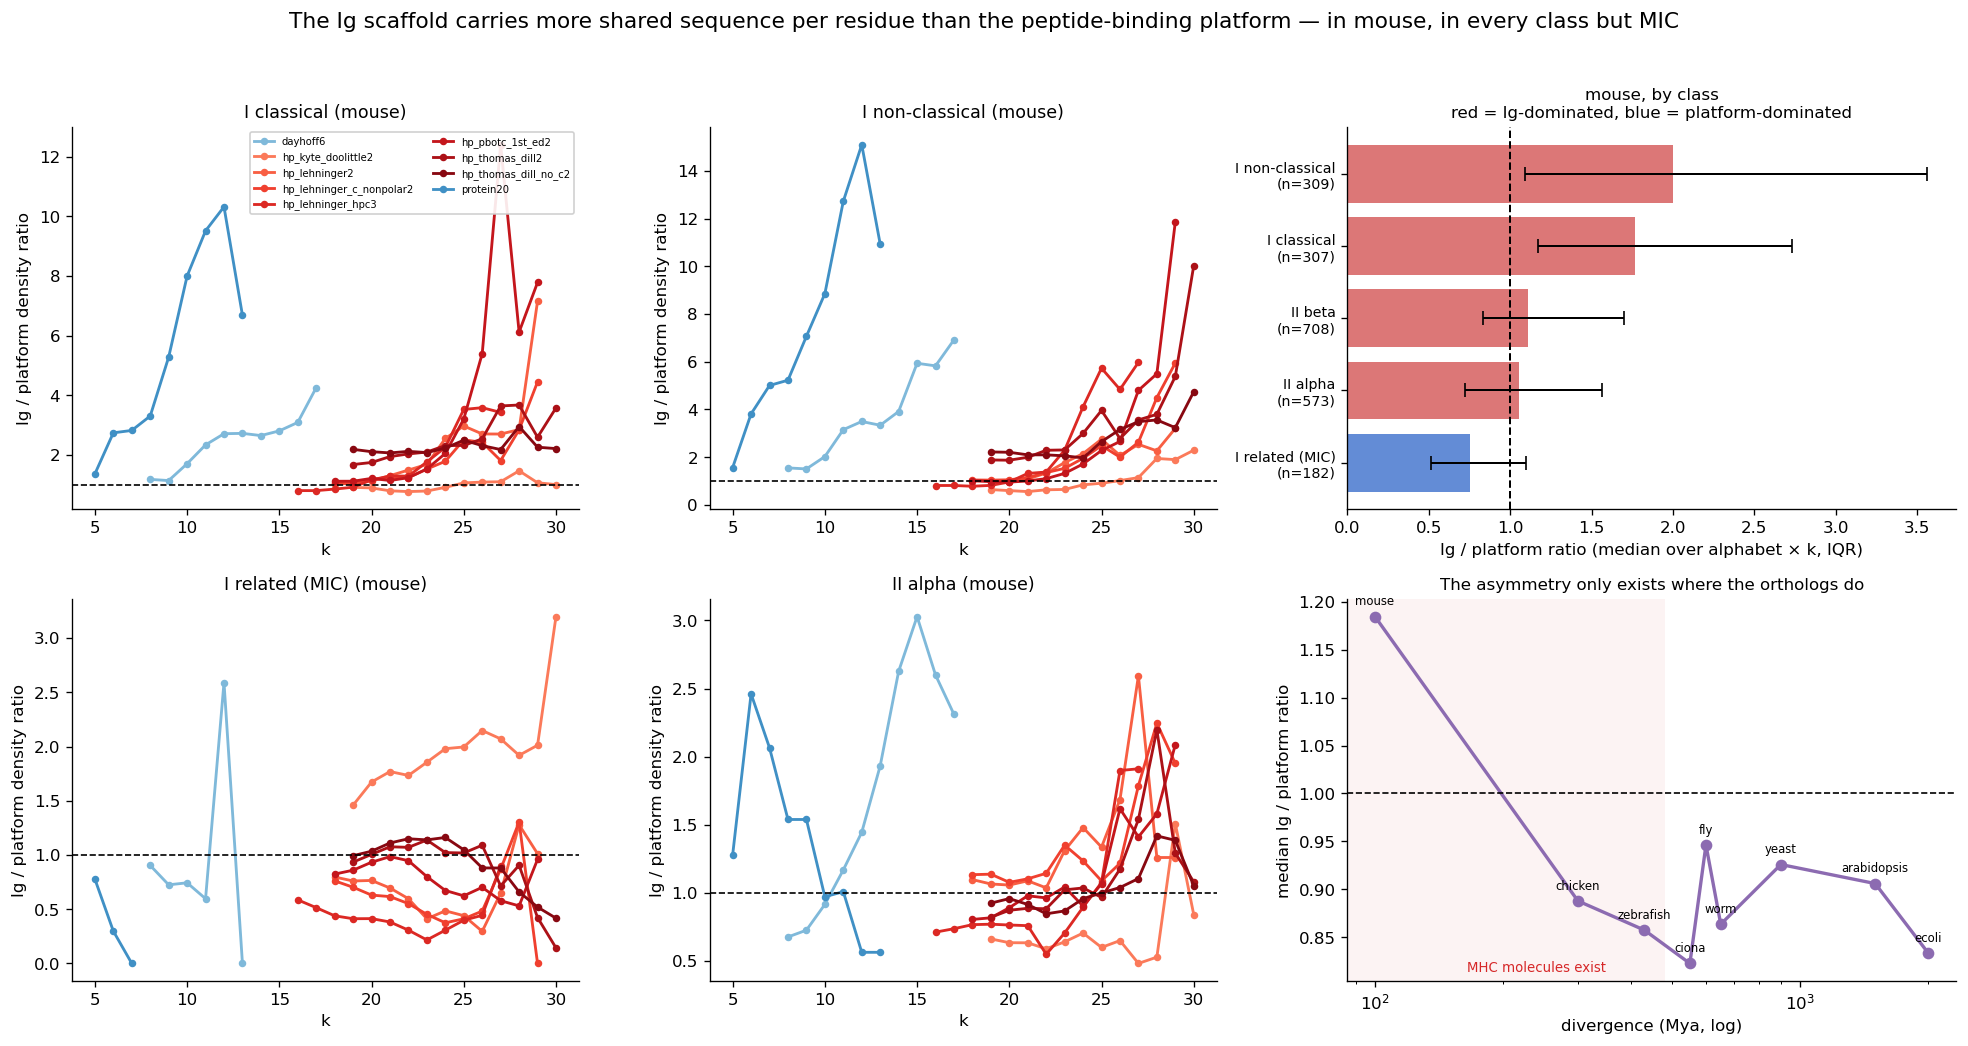

In [3]:
# Overlap between a matched window and a domain, both in 1-based inclusive coordinates.
# The window covers residues region_start+1 .. region_end.
r0, r1 = pl.col("region_start") + 1, pl.col("region_end")
d0, d1 = pl.col("domain_start"), pl.col("domain_end")
overlap = (pl.min_horizontal(r1, d1) - pl.max_horizontal(r0, d0) + 1).clip(lower_bound=0)

dens = (pl.scan_parquet(SWEEP)
        .join(ARCH.lazy(), on="query_acc", how="inner")
        .with_columns(ov=overlap)
        .group_by("species", "alphabet", "ksize", "query_acc", "hgnc_symbol",
                  "mhc_class", "role")
        .agg(matched_residues=pl.col("ov").sum(),
             domain_len=pl.col("domain_end").first() - pl.col("domain_start").first() + 1)
        .with_columns(density=pl.col("matched_residues") / pl.col("domain_len"))
        .collect())

ratio = (dens.pivot(on="role",
                    index=["species", "alphabet", "ksize", "query_acc", "hgnc_symbol", "mhc_class"],
                    values="density")
             .rename({"peptide-binding platform": "platform", "Ig C1-set": "ig"})
             .filter(pl.col("platform").is_not_null() & pl.col("ig").is_not_null()
                     & (pl.col("platform") > 0))
             .with_columns(ig_over_platform=pl.col("ig") / pl.col("platform")))

by_species = (ratio.group_by("species")
              .agg(median=pl.col("ig_over_platform").median(),
                   frac_gt1=(pl.col("ig_over_platform") > 1).mean(),
                   n=pl.len())
              .with_columns(mya=pl.col("species").replace_strict(mu.SPECIES_MYA))
              .sort("mya"))
print("Ig / platform density ratio by target species (the asymmetry tracks where orthologs are):")
with pl.Config(tbl_rows=12, tbl_width_chars=170):
    print(by_species.with_columns([pl.col(c).round(3) for c in ["median", "frac_gt1"]]))

MOUSE = ratio.filter(pl.col("species") == "mouse")
CLASSES = [c for c in mu.MHC_CLASS_ORDER if MOUSE.filter(pl.col("mhc_class") == c).height]
summ = (MOUSE.group_by("mhc_class")
        .agg(median=pl.col("ig_over_platform").median(),
             q1=pl.col("ig_over_platform").quantile(0.25),
             q3=pl.col("ig_over_platform").quantile(0.75),
             n=pl.len(),
             frac_ig_dominated=(pl.col("ig_over_platform") > 1).mean())
        .sort("median", descending=True))
print("\nmouse only, by MHC class:")
with pl.Config(tbl_rows=20, tbl_width_chars=170):
    print(summ.with_columns([pl.col(c).round(3) for c in
                             ["median", "q1", "q3", "frac_ig_dominated"]]))

fig = plt.figure(figsize=(16.5, 8.5))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1.2])
for i, cls in enumerate(CLASSES[:4]):
    ax = fig.add_subplot(gs[i // 2, i % 2])
    sub = MOUSE.filter(pl.col("mhc_class") == cls)
    for a in ALPHABETS:
        sa = (sub.filter(pl.col("alphabet") == a)
                 .group_by("ksize").agg(pl.col("ig_over_platform").median())
                 .sort("ksize"))
        if sa.height == 0:
            continue
        ax.plot(sa["ksize"], sa["ig_over_platform"], marker="o", ms=3.5, lw=1.7,
                color=ALPHA_COLOR[a], label=a if i == 0 else None)
    ax.axhline(1.0, color="black", lw=1.0, ls="--")
    ax.set_title(f"{cls} (mouse)", fontsize=10.5)
    ax.set_xlabel("k")
    ax.set_ylabel("Ig / platform density ratio")
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)
    if i == 0:
        ax.legend(fontsize=6, ncol=2, framealpha=0.9)

ax = fig.add_subplot(gs[0, 2])
y = np.arange(summ.height)
med = summ["median"].to_numpy()
ax.barh(y, med, color=["#D65F5F" if m > 1 else "#4878CF" for m in med], alpha=0.85)
ax.errorbar(med, y, xerr=[med - summ["q1"].to_numpy(), summ["q3"].to_numpy() - med],
            fmt="none", ecolor="black", capsize=4, lw=1.2)
ax.axvline(1.0, color="black", lw=1.2, ls="--")
ax.set_yticks(y)
ax.set_yticklabels([f"{c}\n(n={n:_})" for c, n in zip(summ["mhc_class"], summ["n"])], fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("Ig / platform ratio (median over alphabet × k, IQR)")
ax.set_title("mouse, by class\nred = Ig-dominated, blue = platform-dominated", fontsize=10)
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)

ax = fig.add_subplot(gs[1, 2])
ax.plot(by_species["mya"], by_species["median"], marker="o", ms=6, lw=2,
        color="#8C6BB1")
for r_ in by_species.iter_rows(named=True):
    ax.annotate(r_["species"], (r_["mya"], r_["median"]), textcoords="offset points",
                xytext=(0, 7), ha="center", fontsize=7)
ax.axhline(1.0, color="black", lw=1.0, ls="--")
ax.axvspan(0, 480, color="#D65F5F", alpha=0.07, lw=0)
ax.text(240, ax.get_ylim()[0] + 0.01, "MHC molecules exist", ha="center", fontsize=8,
        color="#D62728")
ax.set_xscale("log")
ax.set_xlabel("divergence (Mya, log)")
ax.set_ylabel("median Ig / platform ratio")
ax.set_title("The asymmetry only exists where the orthologs do", fontsize=10)
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)

fig.suptitle("The Ig scaffold carries more shared sequence per residue than the "
             "peptide-binding platform — in mouse, in every class but MIC", y=1.02, fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "225_ig_vs_platform_density.png", dpi=200)

## 3. Which alphabet reaches the platform? The within-molecule comparison

The ratio controls for how much an alphabet matches overall, because both numbers come from
the same molecule and the same search. Splitting it back into its two absolute densities is
what makes the paper's hypothesis testable here: does an HP alphabet gain on the *platform*
specifically, or does it simply match more of everything?

The third compartment is the control. "Rest of the molecule" is every residue outside both
scored domains — signal peptide, connecting peptide, transmembrane and cytoplasmic tail. If a
coarse alphabet's advantage were generic it would show up there too, and for three of the nine
it does. Read the control column before the headline one.

mouse, class I heavy chains — matched residues per domain residue, by compartment:
shape: (9, 7)
┌──────────────────────────┬──────────┬───────┬────────┬─────┬──────────────────┬────────────────────┐
│ alphabet                 ┆ platform ┆ ig    ┆ rest   ┆ n   ┆ ig_over_platform ┆ platform_over_rest │
│ ---                      ┆ ---      ┆ ---   ┆ ---    ┆ --- ┆ ---              ┆ ---                │
│ str                      ┆ f64      ┆ f64   ┆ f64    ┆ u32 ┆ f64              ┆ f64                │
╞══════════════════════════╪══════════╪═══════╪════════╪═════╪══════════════════╪════════════════════╡
│ hp_kyte_doolittle2       ┆ 88.06    ┆ 64.44 ┆ 37.05  ┆ 72  ┆ 0.73             ┆ 2.38               │
│ hp_lehninger_hpc3        ┆ 13.87    ┆ 17.67 ┆ 162.61 ┆ 72  ┆ 1.27             ┆ 0.09               │
│ hp_lehninger_c_nonpolar2 ┆ 6.54     ┆ 10.72 ┆ 163.42 ┆ 72  ┆ 1.64             ┆ 0.04               │
│ hp_pbotc_1st_ed2         ┆ 9.55     ┆ 16.07 ┆ 8.03   ┆ 72  ┆ 1.68            

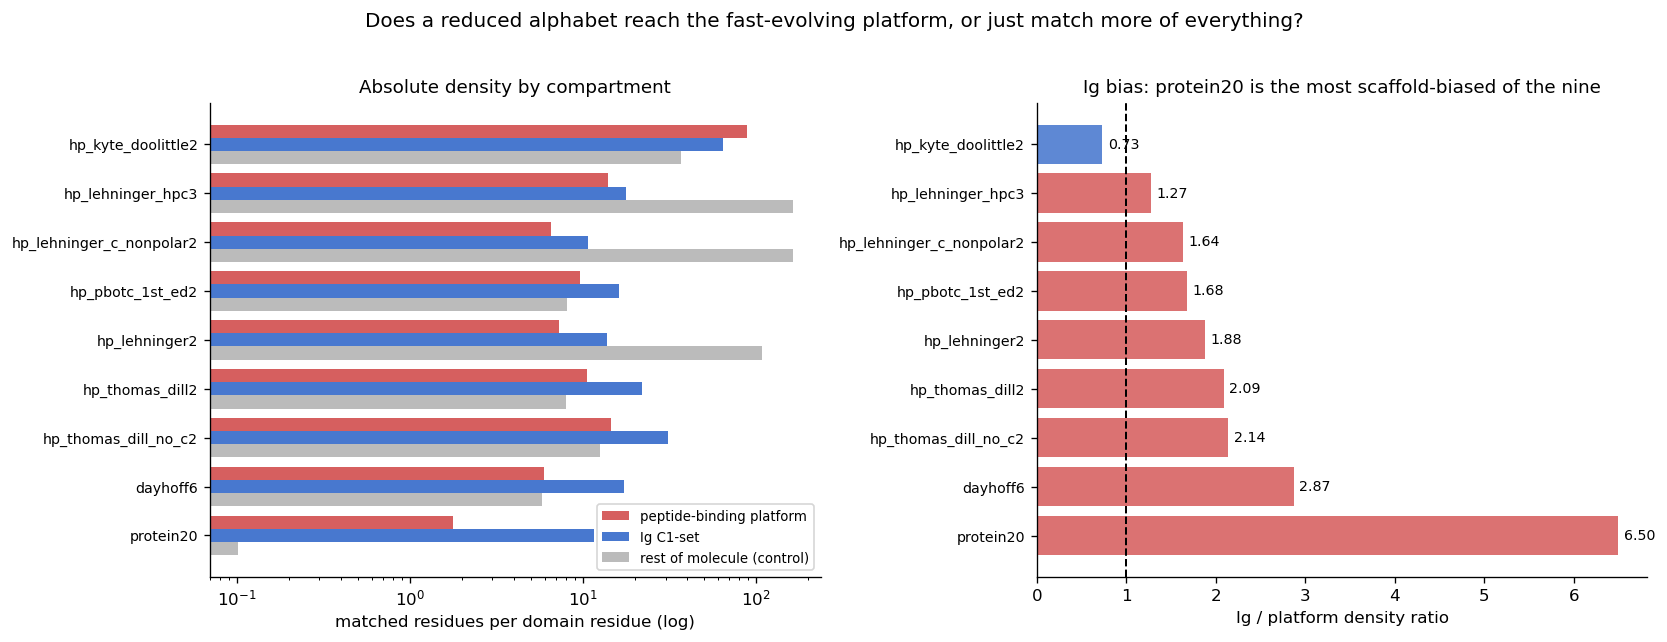

In [4]:
# Third compartment: everything outside both scored domains, per gene. Built by subtracting
# the two domain intervals from the protein, so it needs no extra annotation.
prot = ARCH.group_by("query_acc", "hgnc_symbol", "mhc_class").agg(
    protein_length=pl.col("protein_length").first(),
    dom_residues=(pl.col("domain_end") - pl.col("domain_start") + 1).sum())

CI = (pl.col("mhc_class").str.starts_with("I ") & ~pl.col("mhc_class").str.contains("MIC"))
abs_d = (dens.filter((pl.col("species") == "mouse") & CI)
             .pivot(on="role", index=["alphabet", "ksize", "query_acc"],
                    values=["matched_residues", "density"]))
cols = abs_d.columns
plat_m = [c for c in cols if c.startswith("matched_residues") and "platform" in c][0]
ig_m = [c for c in cols if c.startswith("matched_residues") and "Ig" in c][0]
plat_d = [c for c in cols if c.startswith("density") and "platform" in c][0]
ig_d = [c for c in cols if c.startswith("density") and "Ig" in c][0]

# Total matched residues per gene, to derive the "rest of molecule" compartment.
tot = (pl.scan_parquet(SWEEP)
       .filter(pl.col("species") == "mouse")
       .with_columns(win=pl.col("region_end") - pl.col("region_start"))
       .group_by("alphabet", "ksize", "query_acc")
       .agg(total_matched=pl.col("win").sum())
       .collect())

comp = (abs_d.join(tot, on=["alphabet", "ksize", "query_acc"], how="inner")
             .join(prot, on="query_acc", how="inner")
             .with_columns(
                 rest_matched=(pl.col("total_matched") - pl.col(plat_m) - pl.col(ig_m))
                                .clip(lower_bound=0),
                 rest_len=(pl.col("protein_length") - pl.col("dom_residues")).clip(lower_bound=1))
             .with_columns(rest_density=pl.col("rest_matched") / pl.col("rest_len")))

tbl = (comp.group_by("alphabet")
       .agg(platform=pl.col(plat_d).median(), ig=pl.col(ig_d).median(),
            rest=pl.col("rest_density").median(), n=pl.len())
       .with_columns(ig_over_platform=(pl.col("ig") / pl.col("platform")),
                     platform_over_rest=(pl.col("platform") / pl.col("rest")))
       .sort("ig_over_platform"))
print("mouse, class I heavy chains — matched residues per domain residue, by compartment:")
with pl.Config(tbl_rows=20, tbl_width_chars=190):
    print(tbl.with_columns([pl.col(c).round(2) for c in
                            ["platform", "ig", "rest", "ig_over_platform", "platform_over_rest"]]))
p20 = tbl.filter(pl.col("alphabet") == "protein20")
if p20.height:
    print(f"\nRelative to protein20 (platform {p20['platform'][0]:.2f}, ig {p20['ig'][0]:.2f}):")
    for r_ in tbl.iter_rows(named=True):
        print(f"  {r_['alphabet']:26s} platform x{r_['platform']/p20['platform'][0]:6.2f}   "
              f"Ig x{r_['ig']/p20['ig'][0]:6.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
ax = axes[0]
yv = np.arange(tbl.height)
w = 0.27
for off, col, lab, colr in [(-w, "platform", "peptide-binding platform", "#D65F5F"),
                            (0.0, "ig", "Ig C1-set", "#4878CF"),
                            (w, "rest", "rest of molecule (control)", "#bbbbbb")]:
    ax.barh(yv + off, tbl[col], w, color=colr, label=lab)
ax.set_yticks(yv); ax.set_yticklabels(tbl["alphabet"], fontsize=8.5)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("matched residues per domain residue (log)")
ax.set_title("Absolute density by compartment", fontsize=11)
ax.legend(fontsize=8)

ax = axes[1]
ax.barh(yv, tbl["ig_over_platform"],
        color=["#D65F5F" if v > 1 else "#4878CF" for v in tbl["ig_over_platform"]], alpha=0.88)
ax.axvline(1.0, color="black", lw=1.2, ls="--")
for i, v in enumerate(tbl["ig_over_platform"]):
    ax.text(v + 0.06, i, f"{v:.2f}", va="center", fontsize=8.5)
ax.set_yticks(yv); ax.set_yticklabels(tbl["alphabet"], fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("Ig / platform density ratio")
ax.set_title("Ig bias: protein20 is the most scaffold-biased of the nine", fontsize=11)
for a_ in axes:
    for s_ in ("right", "top"):
        a_.spines[s_].set_visible(False)
fig.suptitle("Does a reduced alphabet reach the fast-evolving platform, or just match more "
             "of everything?", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "225_platform_reach_by_alphabet.png", dpi=200)

## 4. Query and target side of the same regions (after 212 §4)

The density ratio is a query-side summary. This panel opens it up: where along the molecule
the matched windows actually fall, on the human query **and** on the target protein they
matched, for the same set of regions.

Domain bands on both sides come from each side's own annotation — the human Pfam truth for
the query, the target species' own Pfam domain map for the target. Neither side's boundaries
are assumed from the other, which is the mistake 212 §4 was written to avoid.

HLA-A vs mouse, hp_pbotc_1st_ed2 k=19: 3_438 matched windows over 2_374 target proteins
Top targets and their annotated domains:
shape: (2, 4)
┌────────────┬───────────┬────────────┬─────────────────────────────────┐
│ target_acc ┆ n_windows ┆ target_len ┆ pfam                            │
│ ---        ┆ ---       ┆ ---        ┆ ---                             │
│ str        ┆ i64       ┆ i64        ┆ str                             │
╞════════════╪═══════════╪════════════╪═════════════════════════════════╡
│ A0A140LJ72 ┆ 26        ┆ 8478       ┆ PF01390                         │
│ A2ASS6     ┆ 17        ┆ 35213      ┆ PF00041, PF00069, PF02818, PF0… │
└────────────┴───────────┴────────────┴─────────────────────────────────┘


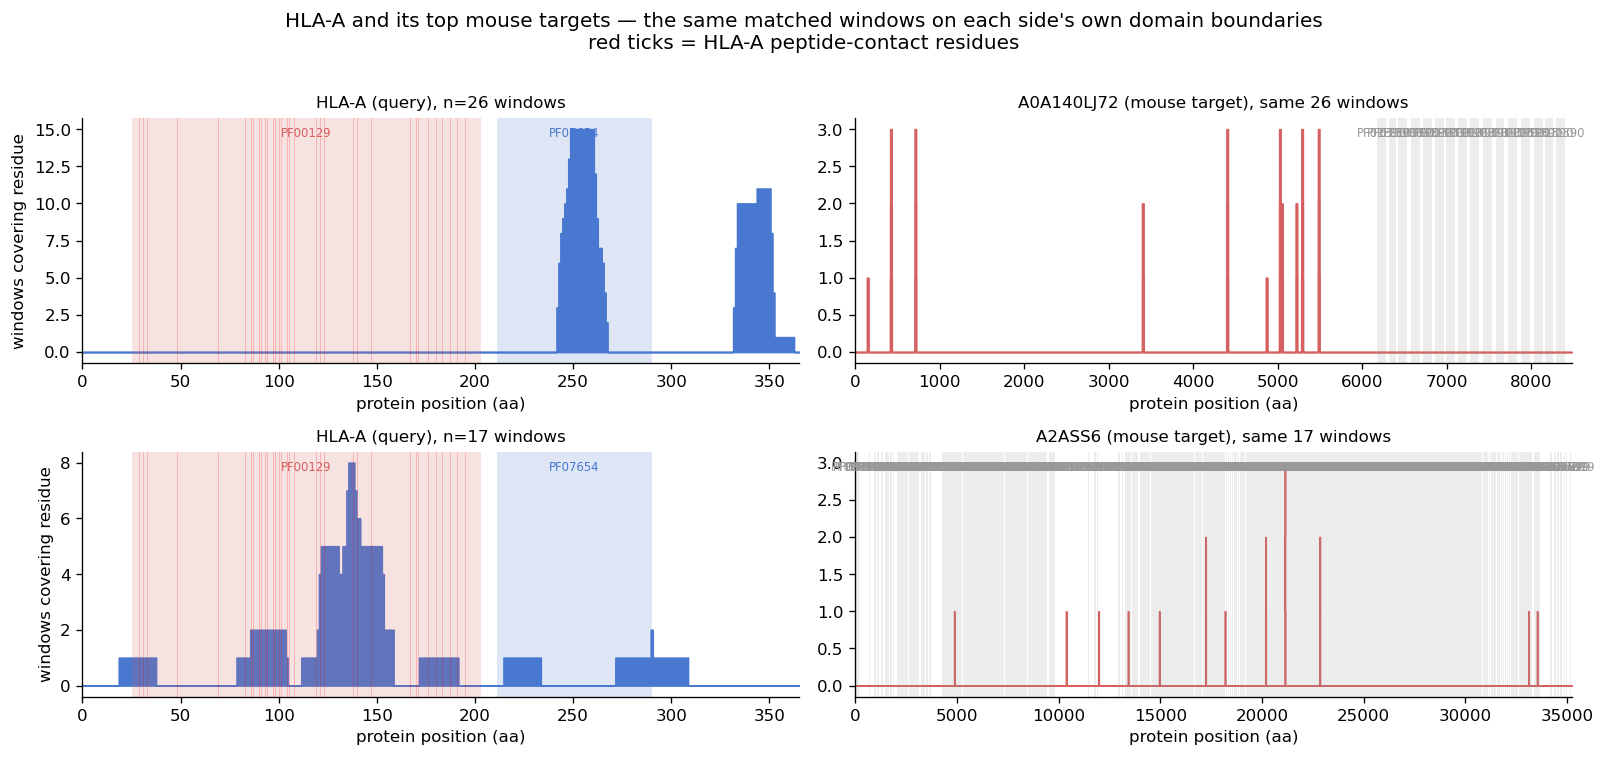

In [5]:
GENE, ACC = "HLA-A", "P04439"
SP = "mouse"
ARM = ("hp_pbotc_1st_ed2", 19)

q = (pl.scan_parquet(SWEEP)
     .filter((pl.col("query_acc") == ACC) & (pl.col("species") == SP)
             & (pl.col("alphabet") == ARM[0]) & (pl.col("ksize") == ARM[1]))
     .select("target_acc", "region_start", "region_end", "target_start", "target_end")
     .collect())
top = q.group_by("target_acc").len().sort("len", descending=True).head(2)
tmap = mu.load_target_domain_map(SP)
qdom = ARCH.filter(pl.col("query_acc") == ACC)
print(f"{GENE} vs {SP}, {ARM[0]} k={ARM[1]}: {q.height:_} matched windows over "
      f"{q['target_acc'].n_unique():_} target proteins")
print("Top targets and their annotated domains:")
rows = []
for tacc, n in top.iter_rows():
    td = tmap.filter(pl.col("accession") == tacc)
    rows.append({"target_acc": tacc, "n_windows": n,
                 "target_len": td["protein_length"][0] if td.height else None,
                 "pfam": ", ".join(sorted(td["pfam_id"].unique().to_list()))})
print(pl.DataFrame(rows))

L = int(qdom["protein_length"][0])
fig, axes = plt.subplots(len(rows), 2, figsize=(13.5, 3.1 * len(rows)), squeeze=False)
for r, (tacc, n) in enumerate(top.iter_rows()):
    sub = q.filter(pl.col("target_acc") == tacc)
    td = tmap.filter(pl.col("accession") == tacc)
    TL = int(td["protein_length"][0]) if td.height else int(sub["target_end"].max())

    covq = np.zeros(L + 2)
    covt = np.zeros(TL + 2)
    for s, e, ts, te in sub.select("region_start", "region_end",
                                   "target_start", "target_end").iter_rows():
        covq[s + 1:min(e, L) + 1] += 1
        covt[ts + 1:min(te, TL) + 1] += 1

    ax = axes[r][0]
    ax.fill_between(np.arange(L + 2), covq, color="#4878CF", step="mid")
    for d in qdom.iter_rows(named=True):
        col = mu.DOMAIN_ROLE_COLORS[d["role"]]
        ax.axvspan(d["domain_start"], d["domain_end"], color=col, alpha=0.18, lw=0)
        ax.text((d["domain_start"] + d["domain_end"]) / 2, ax.get_ylim()[1] * 0.92,
                d["pfam_id"], ha="center", fontsize=7, color=col)
    for cpos in ou.CONTACT_PROT:
        ax.axvline(cpos, color="red", lw=0.35, alpha=0.35)
    ax.set_xlim(0, L)
    ax.set_title(f"{GENE} (query), n={n:_} windows", fontsize=10)
    ax.set_ylabel("windows covering residue")

    ax = axes[r][1]
    ax.fill_between(np.arange(TL + 2), covt, color="#D65F5F", step="mid")
    for d in td.iter_rows(named=True):
        role = mu.domain_role(pl.lit(d["pfam_id"]))
        col = mu.DOMAIN_ROLE_COLORS.get(
            pl.select(role).item() or "", "#999999")
        ax.axvspan(d["domain_start"], d["domain_end"], color=col, alpha=0.18, lw=0)
        ax.text((d["domain_start"] + d["domain_end"]) / 2, ax.get_ylim()[1] * 0.92,
                d["pfam_id"], ha="center", fontsize=7, color=col)
    ax.set_xlim(0, TL)
    ax.set_title(f"{tacc} ({SP} target), same {n:_} windows", fontsize=10)
    for a_ in axes[r]:
        a_.set_xlabel("protein position (aa)")
        for s_ in ("right", "top"):
            a_.spines[s_].set_visible(False)
fig.suptitle(f"{GENE} and its top {SP} targets — the same matched windows on each side's "
             f"own domain boundaries\nred ticks = HLA-A peptide-contact residues", y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "225_query_target_paired.png", dpi=200)

## Summary

mouse, 2_079 (gene × alphabet × k) cells:
  median 1.18   IQR 0.84-2.06   fraction > 1: 63.4%
pooled over all nine species (16_069 cells): median 0.91 -- the asymmetry washes out, which is the control, not a null result

By alphabet:
shape: (9, 3)
┌──────────────────────────┬────────┬─────┐
│ alphabet                 ┆ median ┆ n   │
│ ---                      ┆ ---    ┆ --- │
│ str                      ┆ f64    ┆ u32 │
╞══════════════════════════╪════════╪═════╡
│ protein20                ┆ 1.94   ┆ 156 │
│ dayhoff6                 ┆ 1.6    ┆ 188 │
│ hp_thomas_dill2          ┆ 1.28   ┆ 245 │
│ hp_thomas_dill_no_c2     ┆ 1.23   ┆ 248 │
│ hp_lehninger_c_nonpolar2 ┆ 1.2    ┆ 250 │
│ hp_lehninger2            ┆ 1.11   ┆ 246 │
│ hp_kyte_doolittle2       ┆ 1.05   ┆ 251 │
│ hp_pbotc_1st_ed2         ┆ 1.03   ┆ 246 │
│ hp_lehninger_hpc3        ┆ 0.95   ┆ 249 │
└──────────────────────────┴────────┴─────┘


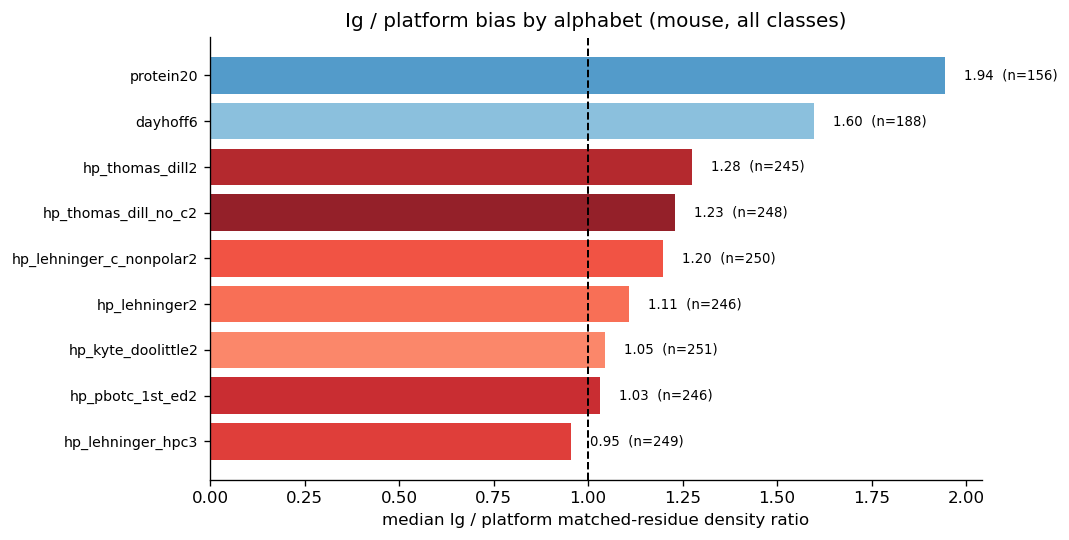

In [6]:
overall = MOUSE["ig_over_platform"]
pooled = ratio["ig_over_platform"]
print(f"mouse, {MOUSE.height:_} (gene × alphabet × k) cells:")
print(f"  median {overall.median():.2f}   IQR {overall.quantile(0.25):.2f}-{overall.quantile(0.75):.2f}"
      f"   fraction > 1: {(overall > 1).mean():.1%}")
print(f"pooled over all nine species ({ratio.height:_} cells): median {pooled.median():.2f} "
      f"-- the asymmetry washes out, which is the control, not a null result")
byalpha = (MOUSE.group_by("alphabet").agg(pl.col("ig_over_platform").median().alias("median"),
                                          pl.len().alias("n"))
           .sort("median", descending=True))
print("\nBy alphabet:")
with pl.Config(tbl_rows=20):
    print(byalpha.with_columns(pl.col("median").round(2)))

fig, ax = plt.subplots(figsize=(9, 4.6))
y = np.arange(byalpha.height)
ax.barh(y, byalpha["median"], color=[ALPHA_COLOR[a] for a in byalpha["alphabet"]], alpha=0.9)
ax.axvline(1.0, color="black", lw=1.2, ls="--")
for i, (a, m, n) in enumerate(byalpha.iter_rows()):
    ax.text(m + 0.05, i, f"{m:.2f}  (n={n:_})", va="center", fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(byalpha["alphabet"], fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("median Ig / platform matched-residue density ratio")
ax.set_title("Ig / platform bias by alphabet (mouse, all classes)")
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "225_ratio_by_alphabet.png", dpi=200)

Three results, and the third qualifies the second.

**The Ig scaffold carries more matched sequence per residue than the peptide-binding platform,
in mouse, in every class except MIC.** That reproduces notebook 212's finding on a different
run, a different truth source and nine species instead of one, including its odd exception:
MICA and MICB sit below 1. The magnitudes here are smaller than 212's because 212 restricted
class I to verified H-2 orthologs while this counts every target in the proteome.

**The asymmetry exists only where the orthologs do.** Pooled over all nine species the median
ratio is 0.91 and the effect looks absent. Split by species it runs 1.18 in mouse down to 0.82
in ciona and *E. coli*. Six of the nine targets contain no MHC molecule at all, so there is no
platform and no MHC Ig domain there to be asymmetric about. Pooling across species would have
reported a null result; the split is what makes it interpretable.

**Reduced alphabets reach the platform, but only three of them do it specifically.** Against
protein20, every reduced alphabet gains far more on the fast-evolving platform than on the
conserved Ig domain — hp_pbotc_1st_ed ×5.4 on the platform against ×1.4 on the Ig,
hp_thomas_dill_no_c ×8.1 against ×2.7. That is the shape the HP hypothesis predicts, measured
without a threshold anywhere.

The control column stops it being a clean win. `hp_lehninger2`, `hp_lehninger_c_nonpolar2` and
`hp_lehninger_hpc3` match the non-domain remainder of the molecule at 108–163 matched residues
per residue, 10–25 times more than they match the platform itself. Their platform reach is not
specific; they match nearly everything, and the signal peptide and transmembrane helix are
exactly what a hydrophobicity alphabet will match indiscriminately. `hp_pbotc_1st_ed`,
`hp_thomas_dill` and `dayhoff6` keep platform and remainder within 1.0–1.3 of each other, so
their platform reach is not explained by promiscuity. protein20 is the most specific of all
(17.6× platform over remainder) and reaches the platform least (density 1.78).

So the defensible claim is narrower than "coarse alphabets win": **a coarse alphabet buys
access to the fast-evolving platform, and whether that access is specific depends on which
coarse alphabet.** The three that pass the control are the ones worth carrying forward.